# DIGITAL TRANSACTION RISK ANALYSIS
## Unit V: Multivariate Analysis — Dimensionality Reduction & Pattern Discovery (PCA)

**Goal (Unit V):** Apply exactly one multivariate technique for **dimensionality reduction** and **pattern discovery** (not necessarily predictive performance).

.
**Technique used:** Principal Component Analysis (PCA).

In [10]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA LOADING
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Export directory for the Overleaf report assets
FIG_DIR = Path('overleaf') / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv('fraudTrain.csv')

# Sample data for visualization (to keep PCA plots clear)
df_sample = df.groupby('is_fraud', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 5000), random_state=42),
    include_groups=False,
 )

# add the label back (include_groups=False drops the grouping column)
df_sample['is_fraud'] = df.loc[df_sample.index, 'is_fraud'].values

print(f"Using stratified sample of {len(df_sample)} records.")
print(f"Exporting report figures to: {FIG_DIR.resolve()}")


Loading dataset...
Using stratified sample of 10000 records.
Exporting report figures to: C:\Users\shubh\OneDrive\Desktop\Digital-Transaction-Risk-Analysis\overleaf\figures


## 1. Feature Engineering: Geographic Distance
**Concept:** Fraud often involves transactions far from the cardholder's home. We calculate the distance between the user's location (`lat`, `long`) and the merchant's location (`merch_lat`, `merch_long`).

In [11]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Approximate radius of Earth in km
    R = 6371.0
    
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df_sample['distance_km'] = haversine_distance(df_sample['lat'], df_sample['long'], 
                                              df_sample['merch_lat'], df_sample['merch_long'])

print("Feature Engineering Complete: 'distance_km' added.")
print(df_sample[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head())


Feature Engineering Complete: 'distance_km' added.
             lat      long  merch_lat  merch_long  distance_km
811778   34.0287 -118.4924  33.287851 -118.740970    85.530738
1101718  36.7154  -89.6287  36.539950  -89.857416    28.234251
800013   39.9636  -79.7853  39.582872  -78.838550    91.317056
398945   48.2777 -112.8456  48.310513 -112.837535     3.697100
207455   36.4715  -82.4834  37.329094  -82.070746   102.175759


## 2. Feature Selection: Correlation Analysis
**Objective:** Use a heatmap to identify which numerical features are most strongly associated with the fraud label.

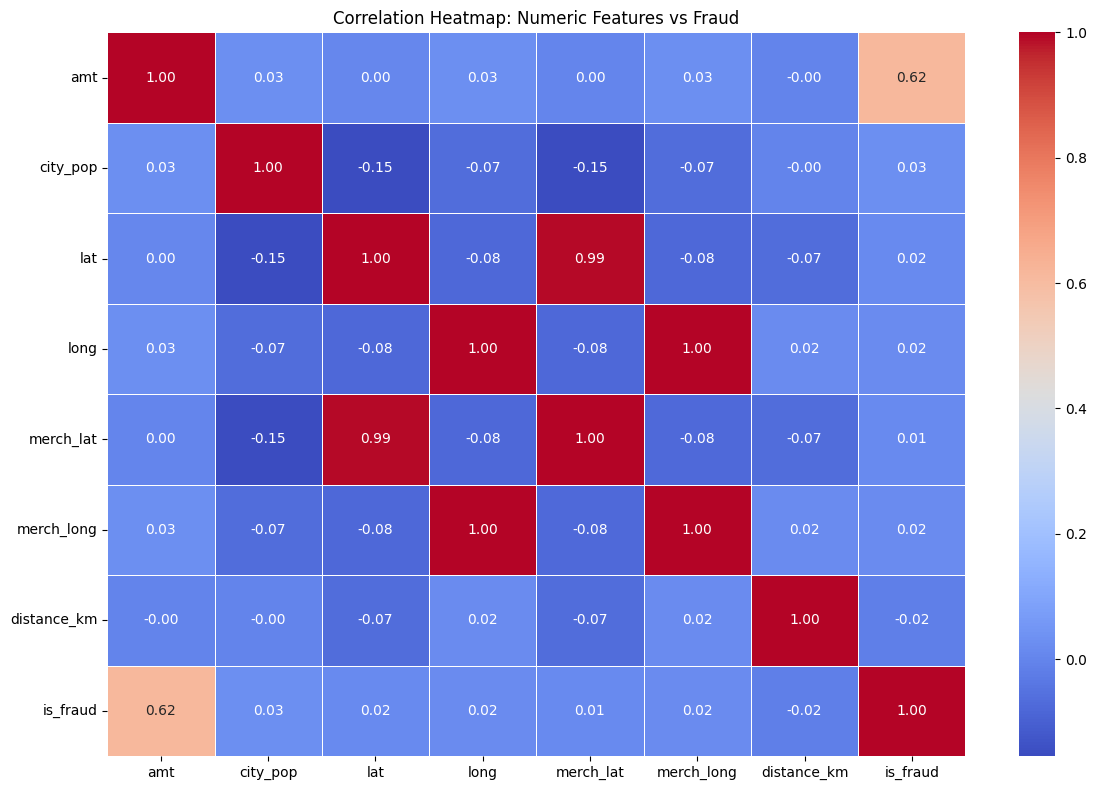

Interpretation: Features with high correlation to 'is_fraud' (like 'amt') are key candidates for selection.
Saved: overleaf/figures/unit5_corr_heatmap.png


In [12]:
plt.figure(figsize=(12, 8))
numeric_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'distance_km', 'is_fraud']
corr = df_sample[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Numeric Features vs Fraud')
plt.tight_layout()
plt.savefig(FIG_DIR / 'unit5_corr_heatmap.png', dpi=200)
plt.show()

print("Interpretation: Features with high correlation to 'is_fraud' (like 'amt') are key candidates for selection.")
print("Saved: overleaf/figures/unit5_corr_heatmap.png")


## 3. Principal Component Analysis (PCA)
**Objective:** Reduce the numeric feature space into a smaller set of orthogonal components that explain the maximum variance.

### 6.3.1 Motivation
This dataset contains multiple correlated continuous features (amount, geography, and population signals). PCA is a good fit because it compresses these correlated dimensions into a small number of interpretable components, helping us discover broad transaction patterns while keeping most of the information (variance).

### 6.3.2 Technical Procedure
We (1) standardised all numeric features (mandatory for PCA), (2) computed the covariance matrix, (3) performed eigendecomposition to obtain eigenvalues/eigenvectors, (4) created a scree plot and identified an elbow (heuristic), (5) selected the number of components needed to reach 80–90% cumulative explained variance, (6) examined feature loadings to interpret PCs, and (7) projected transactions onto PC1–PC2 for visual pattern discovery. Implementation uses NumPy for the linear algebra and Matplotlib/Seaborn for plots.


PCA: DIMENSIONALITY REDUCTION (manual covariance + eigendecomposition)
Covariance matrix shape: (7, 7)


,PC,Eigenvalue,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,2.1675,30.9613%,30.9613%
1,PC2,1.8967,27.0937%,58.0550%
2,PC3,1.0195,14.5632%,72.6182%
3,PC4,0.9896,14.1352%,86.7534%
4,PC5,0.9202,13.1442%,99.8976%
5,PC6,0.0063,0.0903%,99.9879%
6,PC7,0.0008,0.0121%,100.0000%


Saved: overleaf/unit5_pca_variance_table.tex


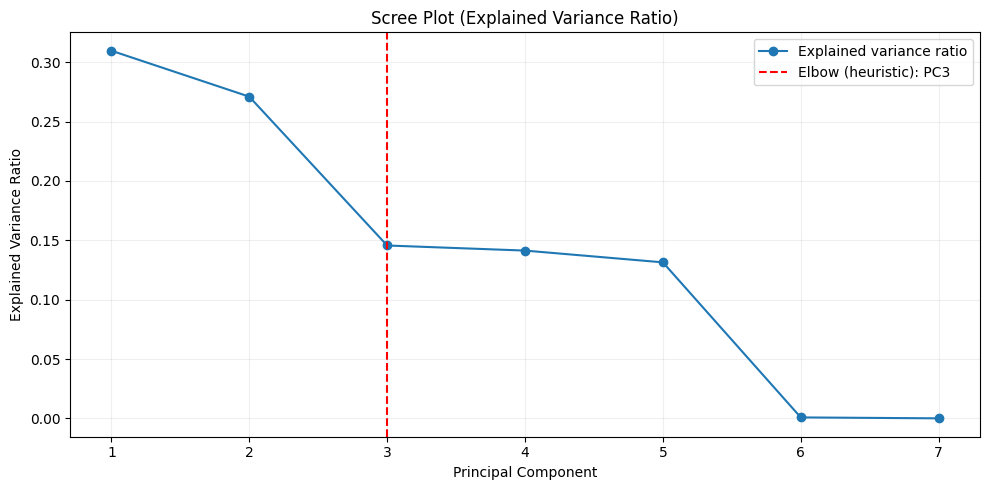

Saved: overleaf/figures/unit5_pca_scree.png
Elbow (heuristic) suggests ~3 components.
Components needed for 80% variance: 4
Components needed for 90% variance: 5


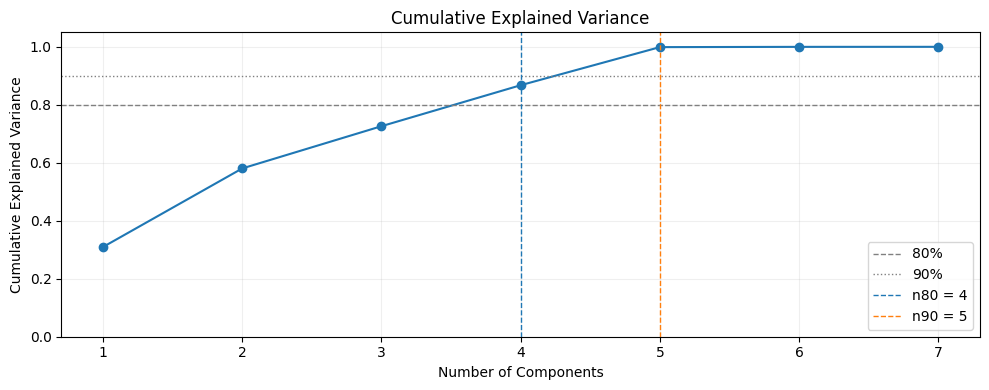

Saved: overleaf/figures/unit5_pca_cumvar.png


,PC1,PC2,PC3
amt,-0.0204,-0.0268,0.7934
city_pop,-0.0848,0.2318,0.4303
lat,0.5256,-0.4434,0.0398
long,-0.4663,-0.5242,0.0219
merch_lat,0.5252,-0.4438,0.0392
merch_long,-0.4661,-0.5243,0.0222
distance_km,-0.0747,0.0476,-0.4257


Saved: overleaf/unit5_pca_loadings_table.tex

Top-3 absolute loadings per component (interpretation helpers):
- PC1: lat(+0.526), merch_lat(+0.525), long(-0.466)
- PC2: merch_long(-0.524), long(-0.524), merch_lat(-0.444)
- PC3: amt(+0.793), city_pop(+0.430), distance_km(-0.426)


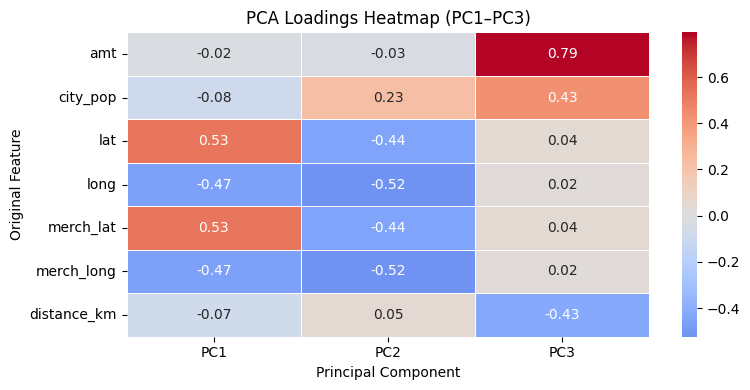

Saved: overleaf/figures/unit5_pca_loadings.png
Projected score matrix shape: (10000, 7)
Cumulative variance (PC1..PC3): 72.62%


In [13]:
print('\n' + '='*60)
print('PCA: DIMENSIONALITY REDUCTION (manual covariance + eigendecomposition)')
print('='*60)

from IPython.display import display

# Step 1 (mandatory): Standardise features
pca_features = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'distance_km']
X = df_sample[pca_features].copy()
y = df_sample['is_fraud'].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)
print(f"Covariance matrix shape: {cov_matrix.shape}")

# Step 3: Eigendecomposition (covariance matrix is symmetric => use eigh)
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# Sort eigenvalues/eigenvectors descending
sort_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sort_idx]
eig_vecs = eig_vecs[:, sort_idx]

# Explained variance ratios
explained_var_ratio = eig_vals / eig_vals.sum()
cumulative_var = np.cumsum(explained_var_ratio)

# Key output: eigenvalues + explained variance table
pca_summary = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(eig_vals) + 1)],
    'Eigenvalue': eig_vals,
    'Explained_Variance_Ratio': explained_var_ratio,
    'Cumulative_Explained_Variance': cumulative_var,
})
display(pca_summary.style.format({
    'Eigenvalue': '{:.4f}',
    'Explained_Variance_Ratio': '{:.4%}',
    'Cumulative_Explained_Variance': '{:.4%}',
}))

# Also export a compact explained-variance table for LaTeX (Overleaf)
variance_table = pca_summary.copy()
variance_table['Explained_Variance_%'] = (variance_table['Explained_Variance_Ratio'] * 100)
variance_table['Cumulative_Explained_Variance_%'] = (variance_table['Cumulative_Explained_Variance'] * 100)
variance_table = variance_table[['PC', 'Eigenvalue', 'Explained_Variance_%', 'Cumulative_Explained_Variance_%']]
variance_table_tex = variance_table.to_latex(
    index=False,
    float_format=lambda v: f"{v:.2f}",
    escape=True,
    caption=None,
    label=None,
 )
Path('overleaf').mkdir(parents=True, exist_ok=True)
Path('overleaf/unit5_pca_variance_table.tex').write_text(variance_table_tex, encoding='utf-8')
print("Saved: overleaf/unit5_pca_variance_table.tex")

# Step 4: Scree plot + elbow (simple knee heuristic: max distance from line)
x_idx = np.arange(1, len(eig_vals) + 1)
y_vals = explained_var_ratio
line_start = np.array([x_idx[0], y_vals[0]])
line_end = np.array([x_idx[-1], y_vals[-1]])
line_vec = line_end - line_start
line_vec_norm = line_vec / np.linalg.norm(line_vec)

distances = []
for xi, yi in zip(x_idx, y_vals):
    point = np.array([xi, yi])
    vec = point - line_start
    proj_len = np.dot(vec, line_vec_norm)
    proj_point = line_start + proj_len * line_vec_norm
    distances.append(np.linalg.norm(point - proj_point))
elbow_pc = int(np.argmax(distances) + 1)

plt.figure(figsize=(10, 5))
plt.plot(x_idx, explained_var_ratio, marker='o', label='Explained variance ratio')
plt.axvline(elbow_pc, color='red', linestyle='--', label=f'Elbow (heuristic): PC{elbow_pc}')
plt.title('Scree Plot (Explained Variance Ratio)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend(loc='best')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'unit5_pca_scree.png', dpi=200)
plt.show()
print("Saved: overleaf/figures/unit5_pca_scree.png")

# Step 5: Cumulative explained variance and n_components for 80–90%
def n_components_for_threshold(threshold: float) -> int:
    return int(np.searchsorted(cumulative_var, threshold) + 1)

n80 = n_components_for_threshold(0.80)
n90 = n_components_for_threshold(0.90)
print(f"Elbow (heuristic) suggests ~{elbow_pc} components.")
print(f"Components needed for 80% variance: {n80}")
print(f"Components needed for 90% variance: {n90}")

plt.figure(figsize=(10, 4))
plt.plot(x_idx, cumulative_var, marker='o')
plt.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80%')
plt.axhline(0.90, color='gray', linestyle=':', linewidth=1, label='90%')
plt.axvline(n80, color='tab:blue', linestyle='--', linewidth=1, label=f'n80 = {n80}')
plt.axvline(n90, color='tab:orange', linestyle='--', linewidth=1, label=f'n90 = {n90}')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig(FIG_DIR / 'unit5_pca_cumvar.png', dpi=200)
plt.show()
print("Saved: overleaf/figures/unit5_pca_cumvar.png")

# Step 6: Loadings (PC coefficients) + heatmap
loadings = pd.DataFrame(
    eig_vecs,
    index=pca_features,
    columns=[f'PC{i}' for i in range(1, len(pca_features) + 1)],
)

display(loadings[['PC1', 'PC2', 'PC3']].style.format('{:.4f}'))

# Export loadings (PC1–PC3) to LaTeX for the report
loadings_small = loadings[['PC1', 'PC2', 'PC3']].copy()
loadings_small.insert(0, 'Feature', loadings_small.index)
loadings_tex = loadings_small.to_latex(index=False, float_format=lambda v: f"{v:.4f}", escape=True)
Path('overleaf/unit5_pca_loadings_table.tex').write_text(loadings_tex, encoding='utf-8')
print("Saved: overleaf/unit5_pca_loadings_table.tex")

print('\nTop-3 absolute loadings per component (interpretation helpers):')
for pc in ['PC1', 'PC2', 'PC3']:
    top3 = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    pieces = []
    for feat in top3:
        sign = '+' if loadings.loc[feat, pc] >= 0 else '-'
        pieces.append(f"{feat}({sign}{abs(loadings.loc[feat, pc]):.3f})")
    print(f"- {pc}: {', '.join(pieces)}")

plt.figure(figsize=(8, 4))
sns.heatmap(loadings[['PC1', 'PC2', 'PC3']], annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('PCA Loadings Heatmap (PC1–PC3)')
plt.ylabel('Original Feature')
plt.xlabel('Principal Component')
plt.tight_layout()
plt.savefig(FIG_DIR / 'unit5_pca_loadings.png', dpi=200)
plt.show()
print("Saved: overleaf/figures/unit5_pca_loadings.png")

# Step 7: Project data onto PCs (scores)
X_scores = X_scaled @ eig_vecs  # columns are PC score coordinates
print(f"Projected score matrix shape: {X_scores.shape}")
print(f"Cumulative variance (PC1..PC3): {cumulative_var[2]*100:.2f}%")

## 4. PCA Visualization (2D Projection)
**Objective:** Visualize the transactions in a 2D PC space (PC1 vs PC2) to inspect high-level structure and any separation between fraud vs non-fraud.

### 6.3.3 Results Interpretation (via Loadings)
Interpretation comes from the **top loadings** in the table/heatmap above. For each component, the three features with the largest absolute coefficients indicate which original variables drive that PC.

Based on the computed loadings in this notebook:
- **PC1** appears dominated by `lat` and `merch_lat` (with `long/merch_long` also contributing), so it behaves like a **geographic position / latitude-alignment** component.
- **PC2** is driven strongly by `long` and `merch_long` (and `merch_lat`), so it behaves like a **geographic position / longitude-alignment** component.
- **PC3** is driven by `amt` and `city_pop` with `distance_km` contributing, so it behaves like a **transaction magnitude / urbanicity vs travel-distance** component.

### 6.3.4 Link to Regression (Section 5)
The correlation heatmap shows very strong collinearity among location variables (e.g., `lat` vs `merch_lat` and `long` vs `merch_long`). PCA can help regression by compressing these correlated predictors into a smaller number of orthogonal components, which can stabilise coefficients and reduce multicollinearity issues.

However, PCA can also reduce interpretability: regression coefficients would apply to PCs (mixtures of original variables) rather than individual features. A practical compromise is to try a regression using the first $n$ PCs (e.g., $n_{80}$ or $n_{90}$ above) and compare stability/fit against the original feature set while keeping the loadings table as the bridge back to business meaning.

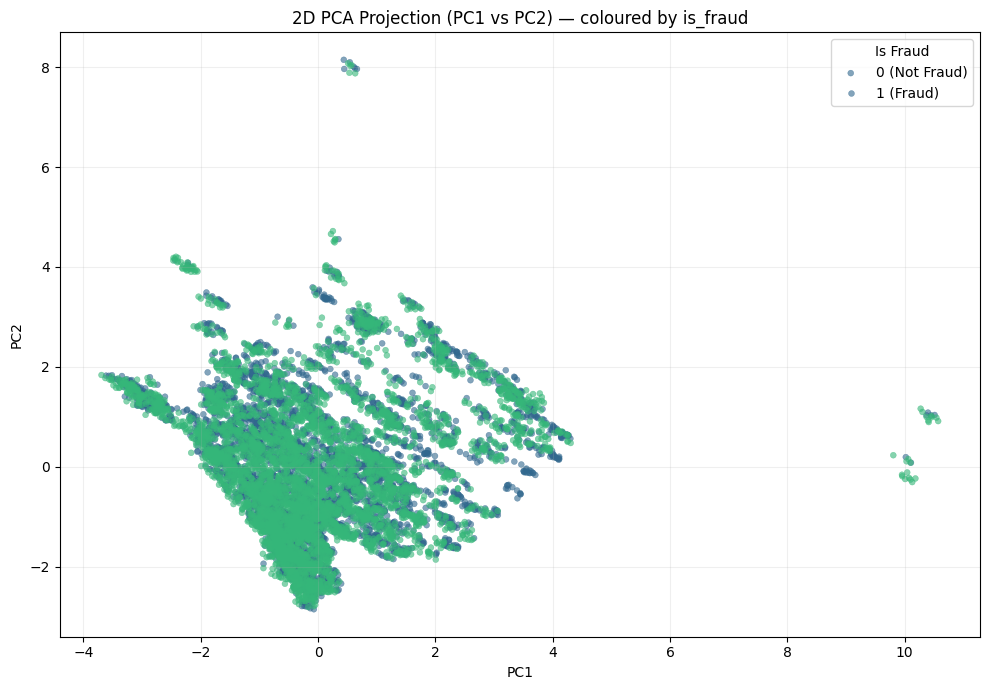

Saved: overleaf/figures/fig5_pca.png
Saved: overleaf/figures/unit5_pca_scatter.png
UNIT V COMPLETE (PCA)
Elbow (heuristic): PC3
n_components for 80% variance: 4
n_components for 90% variance: 5


In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_scores[:, 0],
    y=X_scores[:, 1],
    hue=y,
    alpha=0.6,
    palette='viridis',
    s=18,
    edgecolor=None,
    legend='full',
)
plt.title('2D PCA Projection (PC1 vs PC2) — coloured by is_fraud')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Is Fraud', labels=['0 (Not Fraud)', '1 (Fraud)'])
plt.grid(alpha=0.2)
plt.tight_layout()

# Keep the report's existing filename convention
plt.savefig(FIG_DIR / 'fig5_pca.png', dpi=200)
plt.savefig(FIG_DIR / 'unit5_pca_scatter.png', dpi=200)
plt.show()
print("Saved: overleaf/figures/fig5_pca.png")
print("Saved: overleaf/figures/unit5_pca_scatter.png")

print("=" * 60)
print("UNIT V COMPLETE (PCA)")
print(f"Elbow (heuristic): PC{elbow_pc}")
print(f"n_components for 80% variance: {n80}")
print(f"n_components for 90% variance: {n90}")
print("=" * 60)